In [2]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os
import pandas as pd

file_path = '/content/sample_data/Dataset_Transaksi_Inferensial.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("=== 5 Baris Pertama Data ===")
    display(df.head())
    print("\n" + "="*50 + "\n")
else:
    print(f"[ERROR] Berkas tidak ditemukan di: {file_path}")

=== 5 Baris Pertama Data ===


,ID_Transaksi,Warna_Tombol,Metode_Bayar,Waktu_Akses_Menit,Nominal_Transaksi
0,1,Biru,E-Wallet,5.2,150000
1,2,Hijau,Transfer Bank,12.5,250000
2,3,Biru,Kartu Kredit,3.1,350000
3,4,Hijau,E-Wallet,8.0,175000
4,5,Biru,E-Wallet,4.5,120000


In [5]:
grup_biru = df[df['Warna_Tombol'] == 'Biru']['Nominal_Transaksi']
grup_hijau = df[df['Warna_Tombol'] == 'Hijau']['Nominal_Transaksi']

t_stat, p_value = stats.ttest_ind(grup_biru, grup_hijau)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Kesimpulan: Tolak H0. Terdapat perbedaan signifikan antara tombol Biru dan Hijau.")
else:
    print("Kesimpulan: Gagal Tolak H0. Tidak ada perbedaan signifikan.")

print("\n" + "="*50 + "\n")

T-Statistic: -1.3227
P-Value: 0.2025
Kesimpulan: Gagal Tolak H0. Tidak ada perbedaan signifikan.




In [6]:
ewallet = df[df['Metode_Bayar'] == 'E-Wallet']['Nominal_Transaksi']
transfer = df[df['Metode_Bayar'] == 'Transfer Bank']['Nominal_Transaksi']
kredit = df[df['Metode_Bayar'] == 'Kartu Kredit']['Nominal_Transaksi']

f_stat, p_val_anova = stats.f_oneway(ewallet, transfer, kredit)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value ANOVA: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("Kesimpulan: Tolak H0. Ada perbedaan rata-rata transaksi yang signifikan antar metode pembayaran.")
else:
    print("Kesimpulan: Gagal Tolak H0. Tidak ada perbedaan yang signifikan.")

print("\n" + "="*50 + "\n")

F-Statistic: 76.7215
P-Value ANOVA: 0.0000
Kesimpulan: Tolak H0. Ada perbedaan rata-rata transaksi yang signifikan antar metode pembayaran.




Koefisien Korelasi (r): 0.5556
P-Value: 0.0110


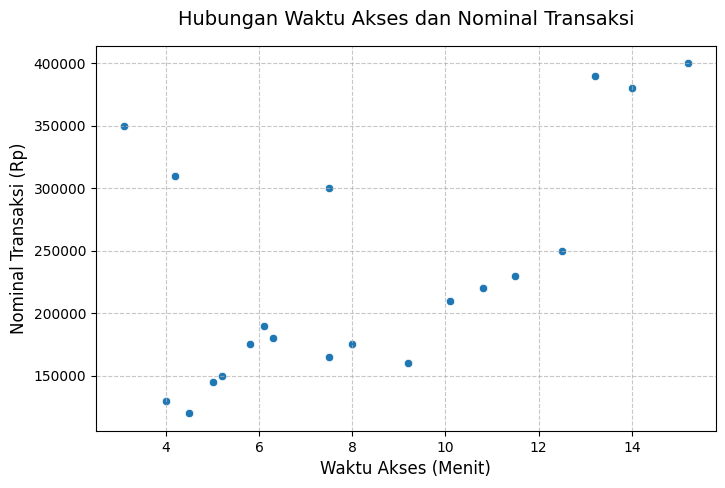

In [8]:
korelasi, p_val_corr = stats.pearsonr(
    df['Waktu_Akses_Menit'],
    df['Nominal_Transaksi']
)

print(f"Koefisien Korelasi (r): {korelasi:.4f}")
print(f"P-Value: {p_val_corr:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Waktu_Akses_Menit',
    y='Nominal_Transaksi',
    data=df
)
plt.title('Hubungan Waktu Akses dan Nominal Transaksi', fontsize=14, pad=15)
plt.xlabel('Waktu Akses (Menit)', fontsize=12)
plt.ylabel('Nominal Transaksi (Rp)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()